# 01 · Ingesta y auditoría de calidad — Etapa ① del pipeline

**Componente del pipeline:** Data Ingestion from EHR Database.

**Entrada:** `data/raw/diabetic_data.csv`, `data/raw/IDS_mapping.csv`
**Salida:** `data/interim/ingesta.pkl` — dataset unificado con eje temporal (`t_idx`, `period`) y objetivo (`target`), que consumen `02_eda` y `03_preprocesamiento`.

Aquí se carga el EHR, se auditan calidad y faltantes, se valida el eje temporal (orden por `encounter_id`) y se define la etiqueta. **No** se limpia ni se codifica: eso es la etapa ② (`03_preprocesamiento`).

In [ ]:
import sys; sys.path.append("..")
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

import sklearn
from sklearn.ensemble import HistGradientBoostingClassifier, IsolationForest
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

from src.paths import RAW, INTERIM, PROCESSED

warnings.filterwarnings("ignore")
SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Paleta categórica validada (orden fijo, apta para daltonismo) y tinta neutra
C1, C2, C3, C4, C5, C6, C7, C8 = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
                                  "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
PALETTE = [C1, C2, C3, C4, C5, C6, C7, C8]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.titleweight": "bold", "axes.titlesize": 11, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED, "lines.linewidth": 2,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})
DATA_DIR = RAW
print("pandas", pd.__version__, "| scikit-learn", sklearn.__version__, "| numpy", np.__version__)

## 1.  Auditoría de calidad de datos

En el dataset se encontro lo siguiente:
- Los faltantes vienen codificados como `"?"` → `na_values="?"`.
- En `max_glu_serum` y `A1Cresult` el valor `"None"` **no es un faltante**: significa *prueba no realizada*, lo cual es informativo. Por eso se desactiva `keep_default_na` (pandas convertiría `"None"` en NaN).

In [2]:
raw = pd.read_csv(DATA_DIR / "diabetic_data.csv", na_values="?", keep_default_na=False, low_memory=False)
print(f"Filas: {raw.shape[0]:,} | Columnas: {raw.shape[1]}")
print(f"Encuentros únicos: {raw.encounter_id.nunique():,} | Pacientes únicos: {raw.patient_nbr.nunique():,}")
raw.head()

Filas: 101,766 | Columnas: 50
Encuentros únicos: 101,766 | Pacientes únicos: 71,518


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
def load_id_mappings(path):
    # El archivo contiene 3 tablas apiladas separadas por líneas vacías
    maps, current = {}, None
    for line in Path(path).read_text(encoding="utf-8").splitlines():
        if not line.strip(", "):
            current = None
            continue
        key, _, desc = line.partition(",")
        if current is None:
            current = key
            maps[current] = {}
        else:
            maps[current][int(key)] = desc.strip().strip('"').strip()
    return maps

ID_MAPS = load_id_mappings(DATA_DIR / "IDS_mapping.csv")
for k, v in ID_MAPS.items():
    print(f"{k}: {len(v)} códigos")

admission_type_id: 8 códigos
discharge_disposition_id: 30 códigos
admission_source_id: 25 códigos


In [4]:
MED_COLS = ["metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride", "acetohexamide",
            "glipizide", "glyburide", "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose", "miglitol",
            "troglitazone", "tolazamide", "examide", "citoglipton", "insulin", "glyburide-metformin",
            "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone"]
NUM_RAW = ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
           "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses"]

def quality_report(df):
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_unicos": df.nunique(),
        "%_faltante": df.isna().mean() * 100,
        "valor_mas_frecuente": df.mode(dropna=False).iloc[0],
        "%_mas_frecuente": [df[c].value_counts(normalize=True, dropna=False).iloc[0] * 100 for c in df],
    }).sort_values(["%_faltante", "%_mas_frecuente"], ascending=False)

qrep = quality_report(raw)
qrep.head(20)

,dtype,n_unicos,%_faltante,valor_mas_frecuente,%_mas_frecuente
weight,object,9,96.8585,NaN,96.8585
medical_specialty,object,72,49.0822,NaN,49.0822
payer_code,object,17,39.5574,NaN,39.5574
race,object,5,2.2336,Caucasian,74.7784
diag_3,object,789,1.3983,250,11.3545
diag_2,object,748,0.3518,276,6.6348
diag_1,object,716,0.0206,428,6.7429
examide,object,1,0.0000,No,100.0000
citoglipton,object,1,0.0000,No,100.0000
acetohexamide,object,2,0.0000,No,99.9990


In [5]:
# Faltantes "ocultos": categorías que semánticamente significan desconocido
hidden_na = {
    "admission_type_id": [5, 6, 8],
    "discharge_disposition_id": [18, 25, 26],
    "admission_source_id": [9, 15, 17, 20, 21],
}
EXPIRED_HOSPICE = [11, 13, 14, 19, 20, 21]  # fallecido u hospicio: no pueden reingresar

checks = {
    "encounter_id duplicados": raw.encounter_id.duplicated().sum(),
    "Filas completamente duplicadas": raw.drop(columns=["encounter_id"]).duplicated().sum(),
    "gender = Unknown/Invalid": (raw.gender == "Unknown/Invalid").sum(),
    "Alta por fallecimiento/hospicio": raw.discharge_disposition_id.isin(EXPIRED_HOSPICE).sum(),
    "Columnas constantes": ", ".join(c for c in raw if raw[c].nunique(dropna=False) == 1),
    "Medicamentos con >99.9% 'No'": ", ".join(c for c in MED_COLS if (raw[c] == "No").mean() > 0.999),
}
for col, codes in hidden_na.items():
    checks[f"{col} desconocido (faltante oculto)"] = raw[col].isin(codes).sum()
checks["A1Cresult = None (no medido)"] = (raw.A1Cresult == "None").sum()
checks["max_glu_serum = None (no medido)"] = (raw.max_glu_serum == "None").sum()
pd.Series(checks, name="valor").to_frame()

,valor
encounter_id duplicados,0
Filas completamente duplicadas,0
gender = Unknown/Invalid,3
Alta por fallecimiento/hospicio,2423
Columnas constantes,"examide, citoglipton"
Medicamentos con >99.9% 'No',"chlorpropamide, acetohexamide, tolbutamide, mi..."
admission_type_id desconocido (faltante oculto),10396
discharge_disposition_id desconocido (faltante oculto),4680
admission_source_id desconocido (faltante oculto),7067
A1Cresult = None (no medido),84748


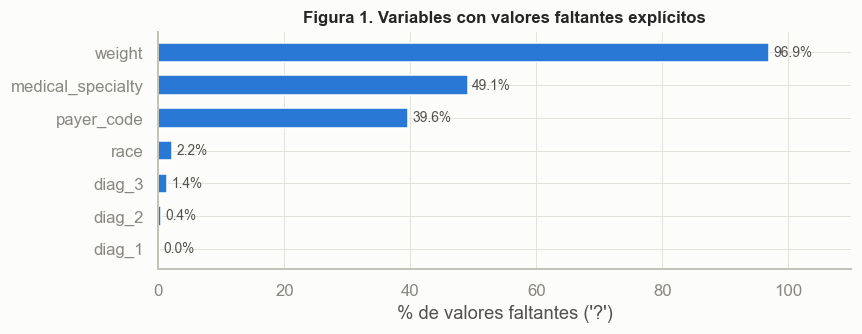

In [6]:
miss = (raw.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.barh(miss.index[::-1], miss.values[::-1], color=C1, height=0.6)
ax.bar_label(bars, fmt="%.1f%%", padding=3, color=INK2, fontsize=9)
ax.set_xlabel("% de valores faltantes ('?')"); ax.set_xlim(0, 110)
ax.set_title("Figura 1. Variables con valores faltantes explícitos")
plt.tight_layout(); plt.show()

**Hallazgos importantes:**
- `weight` tiene ~97 % faltante → se **elimina** (no recuperable).
- `medical_specialty` (~49 %) y `payer_code` (~40 %) tienen faltantes altos pero **no aleatorios** (ver Sección 4: cambian con el tiempo) → se tratan como categoría explícita `Missing`.
- `examide` y `citoglipton` son constantes → sin información, se eliminan.
- Existen faltantes ocultos en IDs de admisión/alta (`NULL`, `Not Mapped`, `Not Available`) → se agrupan como `Unknown`.
- Encuentros con alta por **fallecimiento u hospicio** no pueden reingresar: son anomalías respecto de la etiqueta y se excluyen del modelado.
- 3 registros con sexo inválido → se excluyen.

## 2 Construcción y validación del eje temporal

El dataset cubre 10 años (1999–2008) pero **no incluye fechas**. Para respetar la naturaleza temporal usamos `encounter_id` como **proxy del orden cronológico**: los identificadores de encuentro se asignan de forma creciente en el sistema de origen.


Hemos defeinido que el orden será por `encounter_id` es cronológico, cuando un paciente tiene dos encuentros, el *segundo* debería registrar hospitalizaciones previas en el último año (`number_inpatient ≥ 1`) con mucha más frecuencia que el primero. Si el orden fuese arbitrario, invertirlo no cambiaría esa proporción.

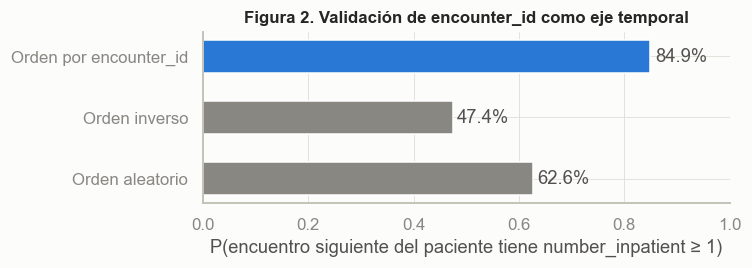

Orden por encounter_id   0.8495
Orden inverso            0.4739
Orden aleatorio          0.6260
dtype: float64

In [7]:
df = raw.sort_values("encounter_id").reset_index(drop=True)
df["t_idx"] = np.arange(len(df))                 # posición cronológica (pseudo-tiempo)
N_PERIODS = 20
df["period"] = df["t_idx"] * N_PERIODS // len(df)  # 20 periodos de igual tamaño (~5 090 encuentros ≈ 6 meses)

def share_next_with_prior_inpatient(d):
    nxt = d.groupby("patient_nbr")["number_inpatient"].shift(-1)
    return (nxt.dropna() >= 1).mean()

val_order = pd.Series({
    "Orden por encounter_id": share_next_with_prior_inpatient(df),
    "Orden inverso": share_next_with_prior_inpatient(df.iloc[::-1]),
    "Orden aleatorio": share_next_with_prior_inpatient(df.sample(frac=1, random_state=SEED)),
})
fig, ax = plt.subplots(figsize=(7, 2.6))
bars = ax.barh(val_order.index[::-1], val_order.values[::-1], color=[MUTED, MUTED, C1], height=0.55)
ax.bar_label(bars, fmt="%.1f%%", labels=[f"{v:.1%}" for v in val_order.values[::-1]], padding=3, color=INK2)
ax.set_xlim(0, 1); ax.set_xlabel("P(encuentro siguiente del paciente tiene number_inpatient ≥ 1)")
ax.set_title("Figura 2. Validación de encounter_id como eje temporal")
plt.tight_layout(); plt.show()
val_order

In [8]:
per = df.groupby("period").agg(n=("encounter_id", "size"),
                               encounter_id_min=("encounter_id", "min"),
                               encounter_id_max=("encounter_id", "max"),
                               pacientes=("patient_nbr", "nunique"))
per.T

period,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
n,5089,5088,5088,5089,5088,5088,5089,5088,5088,5088,5089,5088,5088,5089,5088,5088,5089,5088,5088,5088
encounter_id_min,12522,27172062,43368876,58783392,71759598,84964560,98705880,110203032,126329622,141461340,152389680,161173890,170677014,184657854,205988646,230271984,252314172,275116890,311356052,378967640
encounter_id_max,27170358,43367976,58782366,71757270,84960072,98702742,110201076,126324102,141455694,152388294,161161032,170676276,184657590,205985142,230271972,252308694,275114796,311346542,378962852,443867222
pacientes,4335,4444,4466,4392,4448,4622,4601,4552,4572,4538,4529,4518,4563,4426,4452,4471,4495,4609,4692,4684


**Conclusión:** con el orden por `encounter_id`, el siguiente encuentro del mismo paciente registra hospitalizaciones previas en ~85 % de los casos, frente a ~47 % en orden inverso. Esto nos deja afirmar que el orden es claramente cronológico, por lo que:
- se definen **20 periodos** consecutivos de igual tamaño (cada uno ≈ 6 meses si los encuentros se distribuyen uniformemente en 10 años);
- todas las variables rezagadas, las ventanas deslizantes y la partición train/val/test respetan este orden.

*Limitación clara:* el proxy da orden, no distancia real en días; la duración de cada periodo es aproximada.

## 3. Definición de la variable objetivo

In [ ]:
# Variable objetivo: reingreso en menos de 30 días
df["target"] = (df.readmitted == "<30").astype(int)
print(f"Tasa de reingreso <30: {df.target.mean():.2%} | "
      f"desbalance: {(1 - df.target.mean()) / df.target.mean():.1f} negativos por positivo")

## 4. Exportación para las etapas siguientes

In [ ]:
# Dataset unificado (con eje temporal y objetivo) -> etapas 02 (EDA) y 03 (preprocesamiento)
INTERIM.mkdir(parents=True, exist_ok=True)
df.to_pickle(INTERIM / "ingesta.pkl")
print("Guardado ->", INTERIM / "ingesta.pkl", "|", df.shape)